In [2]:
import pandas as pd
import matplotlib as mpt
import numpy as np
df=pd.read_csv("/content/Task_8_Cleaned_Retail_Sales.csv")

In [3]:
#Step 2 — Select numeric variables
# Select numeric columns for correlation analysis
numeric_df = df.select_dtypes(include='number')

print("Numeric columns:")
print(numeric_df.columns.tolist())

print("\nShape of numeric dataset:", numeric_df.shape)

Numeric columns:
['quantity', 'unit_price', 'discount_pct', 'gross_sales', 'discount_amount', 'net_sales']

Shape of numeric dataset: (120, 6)


In [4]:
#Step 3 — Calculate the Correlation Matrix
# Calculate Pearson correlation matrix
correlation_matrix = numeric_df.corr()

# Display the correlation matrix
correlation_matrix

,quantity,unit_price,discount_pct,gross_sales,discount_amount,net_sales
quantity,1.000000,-0.030070,-0.116160,0.624278,0.302238,0.619867
unit_price,-0.030070,1.000000,-0.069390,0.680383,0.347864,0.672669
discount_pct,-0.116160,-0.069390,1.000000,-0.137345,0.628900,-0.245828
gross_sales,0.624278,0.680383,-0.137345,1.000000,0.498648,0.990649
discount_amount,0.302238,0.347864,0.628900,0.498648,1.000000,0.375725
net_sales,0.619867,0.672669,-0.245828,0.990649,0.375725,1.000000


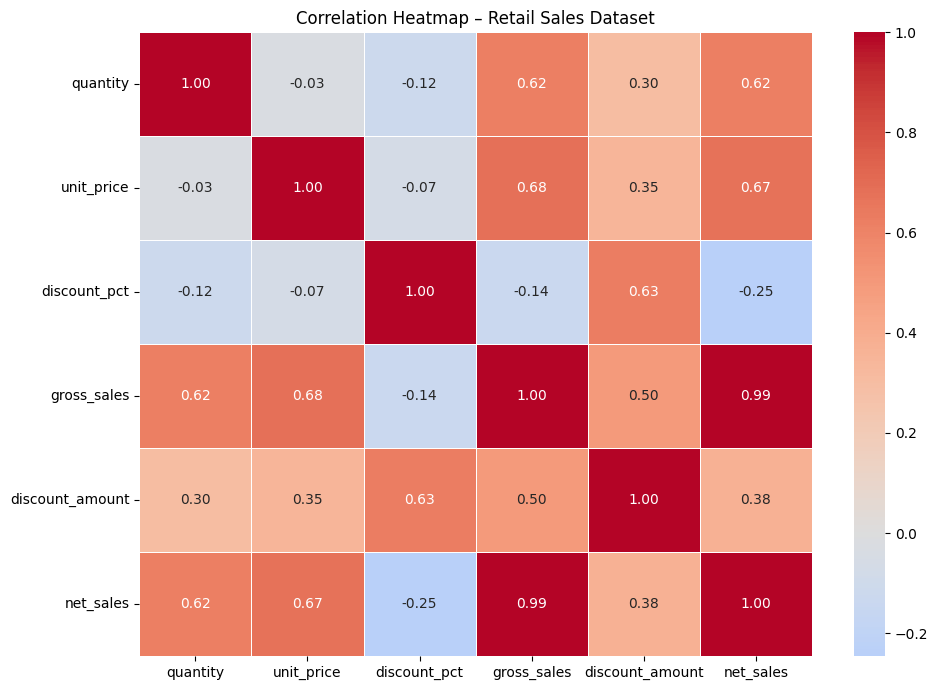

In [5]:
#Step 4 — Create the Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    center=0
)

plt.title("Correlation Heatmap – Retail Sales Dataset")
plt.tight_layout()

plt.show()

In [7]:
#Step 5 — Identify the strongest relationships
# Extract unique correlation pairs
corr_pairs = correlation_matrix.where(
    ~np.tril(np.ones(correlation_matrix.shape)).astype(bool)
).stack().sort_values(ascending=False)

print("Strongest correlation pairs:")
print(corr_pairs)
#This will give us the relationships in descending order and make it easy to identify the strongest correlations.

Strongest correlation pairs:
gross_sales      net_sales          0.990649
unit_price       gross_sales        0.680383
                 net_sales          0.672669
discount_pct     discount_amount    0.628900
quantity         gross_sales        0.624278
                 net_sales          0.619867
gross_sales      discount_amount    0.498648
discount_amount  net_sales          0.375725
unit_price       discount_amount    0.347864
quantity         discount_amount    0.302238
                 unit_price        -0.030070
unit_price       discount_pct      -0.069390
quantity         discount_pct      -0.116160
discount_pct     gross_sales       -0.137345
                 net_sales         -0.245828
dtype: float64


Step 6 — Final interpretation

Based on your actual correlation matrix, these are the key relationships we should document:
| Relationship                 | Correlation | Interpretation                |
| ---------------------------- | ----------: | ----------------------------- |
| Gross Sales ↔ Net Sales      |   **0.991** | Very strong positive          |
| Unit Price ↔ Gross Sales     |   **0.680** | Moderate-to-strong positive   |
| Unit Price ↔ Net Sales       |   **0.673** | Moderate-to-strong positive   |
| Discount % ↔ Discount Amount |   **0.629** | Moderate positive             |
| Quantity ↔ Gross Sales       |   **0.624** | Moderate positive             |
| Quantity ↔ Net Sales         |   **0.620** | Moderate positive             |
| Discount % ↔ Net Sales       |  **-0.246** | Weak-to-moderate negative     |
| Quantity ↔ Unit Price        |  **-0.030** | Almost no linear relationship |


In [ ]:
#mportant modelling finding

#The 0.991 correlation between Gross Sales and Net Sales indicates that these two variables contain almost the same
#linear information. Including both as independent predictors in a model could create multicollinearity.

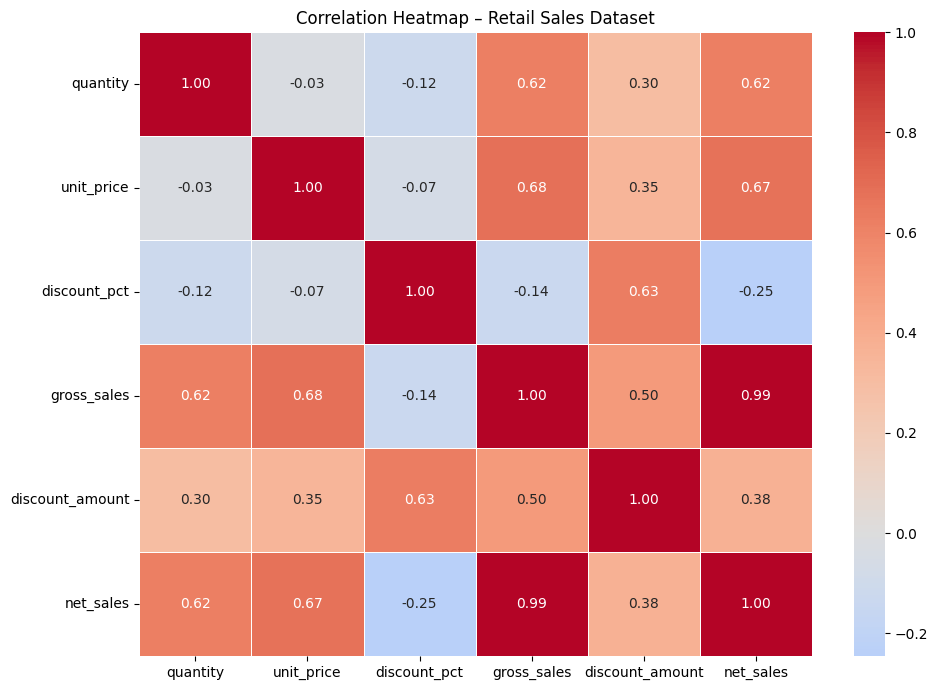

In [8]:
#Step 7 — Save the heatmap as PNG
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    center=0
)

plt.title("Correlation Heatmap – Retail Sales Dataset")
plt.tight_layout()

plt.savefig("Task_11_Correlation_Heatmap.png", dpi=300, bbox_inches="tight")

plt.show()